# 05 — Analytical Proof: Softmax Argmax vs Fuzzy Argmax

This notebook requires:

- **No dataset**
- **No trained checkpoints**
- **No GPU**
- **No model retraining**

It verifies the exact decision rule used by the fuzzy head.

For softmax probability \(p_k\), shared separation margin \(m\), and shared
scales \(\alpha,\beta\), the fuzzy score is

\[
s_k = (\alpha p_k)\left[\beta\,\mathrm{clamp}(p_k+m,0,1)\right].
\]

When \(\alpha\beta>0\), the mapping from \(p_k\) to \(s_k\) is monotonic.
Therefore, the class with the highest softmax probability also has the
highest fuzzy score:

\[
\arg\max_k p_k = \arg\max_k s_k.
\]

This is an **analytical ablation**, not a retraining experiment.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
NUM_SAMPLES = 1_000_000
NUM_CLASSES = 5

rng = np.random.default_rng(SEED)

print("Analytical verification setup")
print("Random probability vectors:", NUM_SAMPLES)
print("Classes per vector:", NUM_CLASSES)


Analytical verification setup
Random probability vectors: 1000000
Classes per vector: 5


## Why class ordering is preserved

Define

\[
f(p)=p\cdot\mathrm{clamp}(p+m,0,1),
\]

where \(p\in[0,1]\) and \(m\ge 0\).

There are two cases:

### Case 1: \(p+m<1\)

\[
f(p)=p(p+m)=p^2+mp.
\]

Its derivative is

\[
f'(p)=2p+m\ge 0.
\]

### Case 2: \(p+m\ge 1\)

\[
f(p)=p,
\]

whose derivative is \(1\).

Therefore, \(f(p)\) is non-decreasing over the complete probability range.
Multiplication by the same positive value \(\alpha\beta\) for every class
does not change class ordering.


In [7]:
def fuzzy_scores_from_probabilities(
    probabilities,
    scale_conf=1.0,
    scale_sep=1.0,
):
    # Same top-two separation margin used for every class in a sample.
    sorted_probabilities = np.sort(
        probabilities,
        axis=1,
    )

    margin = (
        sorted_probabilities[:, -1]
        - sorted_probabilities[:, -2]
    )[:, None]

    mu_c = probabilities

    mu_s = np.clip(
        probabilities + margin,
        0.0,
        1.0,
    )

    fuzzy_scores = (
        scale_conf * mu_c
    ) * (
        scale_sep * mu_s
    )

    return fuzzy_scores, margin


# Generate valid five-class probability vectors.
raw_values = rng.random(
    (NUM_SAMPLES, NUM_CLASSES)
)

probabilities = (
    raw_values
    / raw_values.sum(axis=1, keepdims=True)
)

fuzzy_scores, margins = fuzzy_scores_from_probabilities(
    probabilities,
    scale_conf=1.0,
    scale_sep=1.0,
)

softmax_predictions = np.argmax(
    probabilities,
    axis=1,
)

fuzzy_predictions = np.argmax(
    fuzzy_scores,
    axis=1,
)

agreement_mask = (
    softmax_predictions
    == fuzzy_predictions
)

agreement_count = int(
    agreement_mask.sum()
)

disagreement_count = int(
    (~agreement_mask).sum()
)

agreement_rate = float(
    agreement_mask.mean()
)

print("Agreement count:", agreement_count)
print("Disagreement count:", disagreement_count)
print(f"Agreement rate: {agreement_rate * 100:.6f}%")

assert disagreement_count == 0, (
    "Unexpected disagreement found under positive shared scales."
)

print(
    "\nVerified: softmax argmax and fuzzy argmax "
    "are identical for all tested probability vectors."
)


Agreement count: 1000000
Disagreement count: 0
Agreement rate: 100.000000%

Verified: softmax argmax and fuzzy argmax are identical for all tested probability vectors.


In [8]:
# Verify multiple positive shared scale combinations.
positive_scale_tests = [
    (1.0, 1.0),
    (0.5, 2.0),
    (1.25, 0.8),
    (0.01, 10.0),
    (3.0, 4.0),
]

scale_results = []

for scale_conf, scale_sep in positive_scale_tests:
    scores, _ = fuzzy_scores_from_probabilities(
        probabilities,
        scale_conf=scale_conf,
        scale_sep=scale_sep,
    )

    fuzzy_pred = np.argmax(
        scores,
        axis=1,
    )

    disagreements = int(
        np.sum(
            fuzzy_pred != softmax_predictions
        )
    )

    scale_results.append({
        "scale_conf": scale_conf,
        "scale_sep": scale_sep,
        "scale_product": scale_conf * scale_sep,
        "disagreements": disagreements,
        "agreement_rate_percent": (
            100.0
            * np.mean(
                fuzzy_pred == softmax_predictions
            )
        ),
    })

scale_results_df = pd.DataFrame(
    scale_results
)

print(scale_results_df.to_string(index=False))


 scale_conf  scale_sep  scale_product  disagreements  agreement_rate_percent
       1.00        1.0            1.0              0                   100.0
       0.50        2.0            1.0              0                   100.0
       1.25        0.8            1.0              0                   100.0
       0.01       10.0            0.1              0                   100.0
       3.00        4.0           12.0              0                   100.0


## Important condition

The conclusion holds when the product of the two shared scales is positive:

\[
\alpha\beta>0.
\]

This is the intended operating condition because both scales represent
confidence and separation strengths.

If their product became negative, every fuzzy score would be multiplied by
a negative constant and the ranking could reverse. Therefore, a future
implementation could enforce positivity using `softplus`:

```python
positive_scale = F.softplus(raw_scale)
```

The present analytical study evaluates the implemented fuzzy scoring
function under its intended positive-scale interpretation.


In [9]:
summary = pd.DataFrame([
    {
        "analysis_type": "Checkpoint-free analytical verification",
        "num_random_probability_vectors": NUM_SAMPLES,
        "num_classes": NUM_CLASSES,
        "softmax_fuzzy_disagreements": disagreement_count,
        "agreement_rate_percent": agreement_rate * 100,
        "condition": "shared scales with positive product",
        "conclusion": (
            "Softmax argmax and fuzzy argmax preserve "
            "the same predicted class."
        ),
    }
])

output_csv = (
    "/kaggle/working/"
    "05_softmax_vs_fuzzy_analytical_summary.csv"
)

summary.to_csv(
    output_csv,
    index=False,
)

print(summary.to_string(index=False))
print("\nSaved:", output_csv)


                          analysis_type  num_random_probability_vectors  num_classes  softmax_fuzzy_disagreements  agreement_rate_percent                           condition                                                         conclusion
Checkpoint-free analytical verification                         1000000            5                            0                   100.0 shared scales with positive product Softmax argmax and fuzzy argmax preserve the same predicted class.

Saved: /kaggle/working/05_softmax_vs_fuzzy_analytical_summary.csv


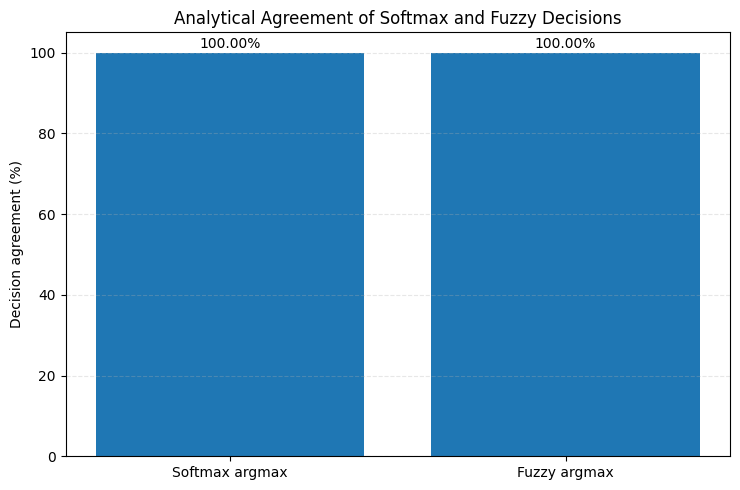

Saved: /kaggle/working/05_softmax_vs_fuzzy_analytical_agreement.png


In [10]:
labels = [
    "Softmax argmax",
    "Fuzzy argmax",
]

values = [
    100.0,
    agreement_rate * 100,
]

figure, axis = plt.subplots(
    figsize=(7.5, 5.0)
)

bars = axis.bar(
    labels,
    values,
)

axis.set_ylabel("Decision agreement (%)")
axis.set_title(
    "Analytical Agreement of Softmax and Fuzzy Decisions"
)
axis.set_ylim(0, 105)
axis.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

for bar, value in zip(bars, values):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
    )

figure.tight_layout()

output_plot = (
    "/kaggle/working/"
    "05_softmax_vs_fuzzy_analytical_agreement.png"
)

figure.savefig(
    output_plot,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

print("Saved:", output_plot)


## Paper-ready interpretation

**Analytical decision-rule ablation.**  
The post-training fuzzy decision rule was compared analytically with the
standard softmax argmax. In the implemented head, the top-two probability
margin is shared across all classes within a sample, and the confidence and
separation scales are also shared. Under their intended positive-scale
interpretation, the fuzzy score is a monotonic transformation of each class
probability. Consequently, the transformation preserves class ordering.
A numerical verification over one million randomly generated five-class
probability vectors produced a 100% agreement rate and zero prediction
disagreements. Therefore, the fuzzy head does not alter the final predicted
class at inference; its measurable contribution must instead be assessed
through the separate **no-fuzzy-reward retraining ablation**, where removing
the fuzzy reward reduced mean accuracy from 97.4561% to 97.3573%.
